# Проект: Интеллектуальный сервис оценки недвижимости

## Постановка задачи
К нам обратился представитель крупного агентства недвижимости со следующей проблемой:

*«Мои риелторы тратят катастрофически много времени на сортировку объявлений и поиск
выгодных предложений. Поэтому их скорость реакции, да и, сказать по правде, качество
анализа не дотягивают до уровня конкурентов. Это сказывается на наших финансовых
показателях»*

**Цель проекта** - построить модель, предсказывающую рыночную стоимость недвижимости по характеристикам объекта, данным объявления и дополнительным признакам, извлечённым из вложенных полей homeFacts и schools

**Практический смысл для заказчика:**
- быстрее фильтровать объявления
- сравнивать цену объявления с оценкой модели
- находить потенциально недооценённые объекты


## Метрики качества и план работы

В проекте используются две метрики:

- **MAPE** - основная бизнес-метрика, показывает относительную ошибку в процентах
- **MAE** - дополнительная метрика, показывает среднюю абсолютную ошибку в долларах

### План работы:
1. Загрузка и первичный осмотр данных
2. Распаковка и парсинг homeFacts и schools
3. Формирование CORE-выборки и генерация признаков
4. EDA и статистическое обоснование части признаков
5. Baseline-модели
6. Сравнение современных моделей в одинаковых условиях
7. Усиление LightGBM и проверка прироста качества
8. Проверка устойчивости победителя
9. Финальное обучение, bundle и пример использования для заказчика


## 1. Импорты и настройки

Ниже подключаются основные библиотеки для анализа данных, визуализации, статистики и машинного обучения

Также фиксируются параметры воспроизводимости и создаётся директория для итоговых артефактов

In [15]:
import ast
import json
import pickle
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import lightgbm as lgb
import catboost
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RANDOM_STATE = 42
N_SPLITS = 5
EARLY_STOP = 300

OUTDIR = Path("output")
OUTDIR.mkdir(exist_ok=True)

DATA_CANDIDATES = [Path("data/real_estate.csv"), Path("real_estate.csv")]

CORE_BOUNDS = {
    "min_price": 76_250,
    "max_price": 1_200_000,
    "min_sqft": 300,
    "max_sqft": 20_000,
    "min_beds": 1,
    "max_beds": 15,
    "exclude_types": ["land", "mobile"]}

print("lightgbm =", lgb.__version__)
print("catboost =", catboost.__version__)
print("output dir =", OUTDIR.resolve())


lightgbm = 4.6.0
catboost = 1.2.8
output dir = D:\Documents\!p\output


Импорты загружены, параметры воспроизводимости зафиксированы, директория для артефактов создана

Далее загружаем датасет и проверяем структуру исходных данных.


## 2. Загрузка данных и первичный осмотр

На этом этапе загружается датасет и выполняется быстрый обзор:
- размер таблицы
- типы колонок
- доля пропусков
- примеры строк
- примеры вложенных полей homeFacts и schools


In [16]:
DATA_PATH = None
for p in DATA_CANDIDATES:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Не найден CSV с данными, проверьте пути")

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print("DATA_PATH:", DATA_PATH)
print("RAW SHAPE:", df_raw.shape)
display(df_raw.head(3))
display(df_raw.info())

missing_share = (
    df_raw.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .to_frame("missing_%"))
display(missing_share.head(20))

for col in ["state", "city", "zipcode", "propertyType"]:
    if col in df_raw.columns:
        print(f"unique({col}) =", df_raw[col].nunique(dropna=True))

if "homeFacts" in df_raw.columns:
    print("\nПримеры homeFacts:")
    for val in df_raw["homeFacts"].dropna().head(2).tolist():
        print(str(val)[:700], "\n")

if "schools" in df_raw.columns:
    print("\nПримеры schools:")
    for val in df_raw["schools"].dropna().head(2).tolist():
        print(str(val)[:700], "\n")


DATA_PATH: data\real_estate.csv
RAW SHAPE: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', '...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'C...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data': {'Distance': ['1.65mi', '1.32mi', '1.01mi'], 'Grades': ['9-12', '3-8', 'PK-8']}, 'name': ['East Valley High School&Extension', 'Eastvalley Middle S...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'factLabel': 'Year built'}, {'factValue': '1967', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Cent...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': {'Distance': ['1.19mi', '2.06mi', '2.63mi'], 'Grades': ['6-8', 'K-5', '9-12']}, 'name': ['Paul Revere Middle School', 'Brentwood Science School', 'Pal...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103114 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  zipcode       377185 non-null  object
 11  beds          285903 non-null  object
 12  state         377185 non-null  object
 13  stories       226469 non-null  object
 14  mls-id        24942 non-null   object
 15  PrivatePool   40311 non-null   object
 16  MlsId         310305 non-null  object
 17  target        374704 non-null  object
dtypes: object(18)
memory usa

None

,missing_%
private pool,98.89
mls-id,93.39
PrivatePool,89.31
fireplace,72.66
stories,39.96
baths,28.19
beds,24.20
MlsId,17.73
sqft,10.76
status,10.58


unique(state) = 39
unique(city) = 2026
unique(zipcode) = 4549
unique(propertyType) = 1280

Примеры homeFacts:
{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]} 

{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '5828 sqft', 'factLabel': 'lotsize'}, {'factValue': '$159/sqft', 'factLabel': 'Price/sqft'}]} 


Примеры schools:
[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.

### Вывод

В данных присутствуют:
- обычные табличные признаки
- строковые числовые поля
- полуструктурированные колонки homeFacts и schools
- категориальные признаки

перед обучением модели нужно аккуратно распаковать вложенные структуры и привести данные к однородному табличному виду

## 3. Вспомогательные функции парсинга

Здесь функции для:
- перевода строковых чисел в числовой формат
- извлечения признаков из homeFacts
- извлечения школьных признаков из schools
- безопасной обработки пропусков и нестандартных значений

преобразуем полуструктурированные признаки в стабильное и интерпретируемое табличное представление


In [17]:
RE_NUM = re.compile(r"[-+]?\d*\.?\d+")
RE_YEAR = re.compile(r"\b(19\d{2}|20\d{2})\b")
RE_RATE = re.compile(r"(\d+(?:\.\d+)?)\s*/\s*10")
RE_DIST = re.compile(r"(\d+(?:\.\d+)?)\s*mi")
RE_PARK = re.compile(r"(\d+)\s*(?:car\s*)?(?:space|spot|vehicle)", re.I)

AC_KW = ["central air", "central ac", "central a/c", "air conditioning", "cooling"]
FA_KW = ["forced air", "forced-air", "heat pump", "baseboard", "radiant",
         "gas heat", "natural gas", "electric heat", "wall furnace"]

# данные могут приходить как в корректном JSON, так и в виде Python-литералов (например, с None вместо null)
# перебор двух парсеров делает код устойчивым к вариациям формата
def safe_parse(text):
    if text is None or pd.isna(text):
        return None
    s = str(text).strip()
    if s in {"", "nan", "None"}:
        return None
    for parser in (json.loads, ast.literal_eval):
        try:
            obj = parser(s)
            if isinstance(obj, (list, dict)):
                return obj
        except Exception:
            pass
    return None

def parse_num(val):
    if val is None or pd.isna(val):
        return np.nan
    m = RE_NUM.search(str(val).replace(",", ""))
    return float(m.group()) if m else np.nan

def parse_price(val):
    if val is None or pd.isna(val):
        return np.nan
    m = RE_NUM.search(str(val).replace("$", "").replace(",", ""))
    return float(m.group()) if m else np.nan

def parse_stories(val):
    if val is None or pd.isna(val):
        return np.nan
    s = str(val).lower()
    word_map = {"one": 1, "two": 2, "three": 3, "four": 4}
    for k, v in word_map.items():
        if k in s:
            return float(v)
    m = RE_NUM.search(s)
    return float(m.group()) if m else np.nan

def normalize_property_type(val):
    if val is None or pd.isna(val):
        return "other"
    s = str(val).lower()
    if any(x in s for x in ["single", "house", "detach"]):
        return "singlefamily"
    if "condo" in s:
        return "condo"
    if any(x in s for x in ["townhouse", "townhome", "town"]):
        return "townhouse"
    if "multi" in s:
        return "multifamily"
    if "mobile" in s:
        return "mobile"
    if "land" in s:
        return "land"
    return "other"

# обрабатывает NaN и деление на ноль
def safe_div(x, y, fallback=np.nan):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    out = np.full(len(x), fallback, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y) | (y == 0))
    out[mask] = x[mask] / y[mask]
    return out

def parse_lot_size_to_sqft(val):
    if val is None or pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in {"", "none", "nan", "no data", "-", "-", "--"}:
        return np.nan
    s_clean = s.replace(",", "").strip()
    m = RE_NUM.search(s_clean)
    if not m:
        return np.nan
    x = float(m.group())
    if "acre" in s_clean:
        x = x * 43560.0
        return x if x > 0 else np.nan
    sqft_markers = ["sqft", "sq ft", "sq. ft", "square feet", "square foot", "sqft lot"]
    if any(marker in s_clean for marker in sqft_markers):
        return x if x > 0 else np.nan
    if 100 <= x <= 5_000_000:
        return x
    return np.nan

def fit_lot_bounds_from_homefacts(series, lower_percentile=1, upper_percentile=99):
    raw = []
    for text in series.dropna():
        facts = safe_parse(text)
        if not facts:
            continue
        if isinstance(facts, dict):
            facts = facts.get("atAGlanceFacts", facts.get("homeFacts", []))
        if not isinstance(facts, list):
            continue
        for f in facts:
            if not isinstance(f, dict):
                continue
            label = str(f.get("factLabel", "")).lower()
            if "lot" not in label:
                continue
            val = f.get("factValue", "")
            x = parse_lot_size_to_sqft(val)
            if pd.notna(x) and 100 < x < 10_000_000:
                raw.append(x)
    if len(raw) < 100:
        return 400.0, 5_000_000.0
    return float(np.percentile(raw, lower_percentile)), float(np.percentile(raw, upper_percentile)) #  вместо жёстко заданных констант границы вычисляются из самих данных (1-й и 99-й перцентили)

def parse_homefacts(text, lot_lo=400.0, lot_hi=5_000_000.0):
    res = {
        "hfyearbuilt": np.nan,
        "hfremodeledyear": np.nan,
        "hflotsqft": np.nan,
        "hfhascentralac": 0,
        "hfhasforcedair": 0,
        "hfhasgarage": 0,
        "hfhasattachedgarage": 0,
        "hfhasdetachedgarage": 0,
        "hfhascarport": 0,
        "hfhasstreet": 0,
        "hfparkingspaces": np.nan,
        "hfhasfireplace": 0,
        "hfhaspool": 0,
        "hfhasbasement": 0,
        "hfhaslaundry": 0}
    if text is None or pd.isna(text):
        return res

    facts = safe_parse(text)
    if facts is None:
        return res
    if isinstance(facts, dict):
        facts = facts.get("atAGlanceFacts", facts.get("homeFacts", []))
    if not isinstance(facts, list):
        return res

    for item in facts:
        if not isinstance(item, dict):
            continue
        label = str(item.get("factLabel", "")).lower().strip()
        value = str(item.get("factValue", "")).strip()
        value_lower = value.lower()

        if "year built" in label or "yr built" in label:
            m = RE_YEAR.search(value)
            if m and pd.isna(res["hfyearbuilt"]):
                res["hfyearbuilt"] = float(m.group())

        elif any(x in label for x in ["remodel", "renovat", "updated"]):
            m = RE_YEAR.search(value)
            if m and pd.isna(res["hfremodeledyear"]):
                res["hfremodeledyear"] = float(m.group())

        elif "lot" in label:
            lot_val = parse_lot_size_to_sqft(value)
            if pd.notna(lot_val) and lot_lo < lot_val < lot_hi:
                res["hflotsqft"] = lot_val

        elif any(x in label for x in ["heat", "cool", "air", "climate", "hvac"]):
            sv = (label + " " + value).lower()
            if any(kw in sv for kw in AC_KW):
                res["hfhascentralac"] = 1
            if any(kw in sv for kw in FA_KW):
                res["hfhasforcedair"] = 1

        if "fireplace" in label:
            res["hfhasfireplace"] = 1
        if "pool" in label:
            res["hfhaspool"] = 1
        if "basement" in label:
            res["hfhasbasement"] = 1
        if any(x in label for x in ["laundry", "washer"]):
            res["hfhaslaundry"] = 1

        if "parking" in label or "garage" in label or "carport" in label:
            s = (label + " " + value_lower)
            res["hfhasgarage"] = int("garage" in s or res["hfhasgarage"] == 1)
            res["hfhasattachedgarage"] = int(("attached" in s) or res["hfhasattachedgarage"] == 1)
            res["hfhasdetachedgarage"] = int(("detached" in s) or res["hfhasdetachedgarage"] == 1)
            res["hfhascarport"] = int(("carport" in s) or res["hfhascarport"] == 1)
            res["hfhasstreet"] = int(("street" in s) or res["hfhasstreet"] == 1)
            m = RE_PARK.search(s)
            if m:
                res["hfparkingspaces"] = float(m.group(1))

    return res

def parse_schools(text):
    res = {
        "schoolratingavg": np.nan,
        "schoolratingmax": np.nan,
        "schoolratingcount": 0.0,
        "schoolmindistmi": np.nan,
        "schoolhashighschool": 0,
    }
    obj = safe_parse(text)
    if obj is None or not isinstance(obj, list):
        return res

    ratings = []
    dists = []
    has_hs = 0

    for block in obj:
        if not isinstance(block, dict):
            continue

        rating_vals = block.get("rating", [])
        if isinstance(rating_vals, str):
            rating_vals = [rating_vals]
        for rv in rating_vals:
            s = str(rv).strip()
            if s.upper() in {"NR", "NA", "N/A", "NONE/10", "NONE"} or s == "":
                continue
            m = RE_RATE.search(s)
            if m:
                val = float(m.group(1))
                if 0 <= val <= 10:
                    ratings.append(val)
                continue
            m2 = re.fullmatch(r"(\d+(?:\.\d+)?)", s)
            if m2:
                val = float(m2.group(1))
                if 0 <= val <= 10:
                    ratings.append(val)

        data = block.get("data", {})
        if isinstance(data, dict):
            dist_vals = data.get("Distance", [])
            grade_vals = data.get("Grades", [])
            if isinstance(dist_vals, str):
                dist_vals = [dist_vals]
            if isinstance(grade_vals, str):
                grade_vals = [grade_vals]

            for dv in dist_vals:
                s = str(dv).replace(" ", "")
                m = RE_DIST.search(s)
                if m:
                    dists.append(float(m.group(1)))

            for gv in grade_vals:
                g = str(gv).lower()
                if any(x in g for x in ["9-12", "10-12", "high school", "9 to 12", "11-12", "11 to 12"]):
                    has_hs = 1

        names = block.get("name", [])
        if isinstance(names, str):
            names = [names]
        for nm in names:
            if "high school" in str(nm).lower():
                has_hs = 1

    if ratings:
        res["schoolratingavg"] = float(np.mean(ratings))
        res["schoolratingmax"] = float(np.max(ratings))
        res["schoolratingcount"] = float(len(ratings))
    if dists:
        res["schoolmindistmi"] = float(np.min(dists))
    res["schoolhashighschool"] = has_hs
    return res


Функции парсинга готовы

Далее применяем их к датасету, формируем CORE-выборку и строим исходное признаковое пространство


## 4. Применяем парсинг и строим CORE-выборку

На этом этапе:
- распаковываются homeFacts и schools
- создаются базовые числовые признаки
- формируется CORE-выборка
- добавляются производные признаки, missing-флаги и компактный feature pack

Здесь же дополнительно проверим корректность парсинга lotSize


In [18]:
df = df_raw.copy()

price_source = "price" if "price" in df.columns else "target"
df["price"] = df[price_source].apply(parse_price)
df["sqftClean"] = df["sqft"].apply(parse_num) if "sqft" in df.columns else np.nan
df["bedsClean"] = df["beds"].apply(parse_num) if "beds" in df.columns else np.nan
df["bathsClean"] = df["baths"].apply(parse_num) if "baths" in df.columns else np.nan
df["storiesClean"] = df["stories"].apply(parse_stories) if "stories" in df.columns else np.nan
df["propertyTypeNorm"] = df["propertyType"].apply(normalize_property_type) if "propertyType" in df.columns else "other"

lot_lo, lot_hi = fit_lot_bounds_from_homefacts(df["homeFacts"]) if "homeFacts" in df.columns else (400.0, 5_000_000.0)
print(f"lot bounds: [{lot_lo:,.0f}, {lot_hi:,.0f}]")

hf_list = [parse_homefacts(x, lot_lo=lot_lo, lot_hi=lot_hi) for x in df["homeFacts"]] if "homeFacts" in df.columns else [{} for _ in range(len(df))]
sc_list = [parse_schools(x) for x in df["schools"]] if "schools" in df.columns else [{} for _ in range(len(df))]

hf = pd.DataFrame(hf_list, index=df.index)
sc = pd.DataFrame(sc_list, index=df.index)

for col in hf.columns:
    df[col] = hf[col]
for col in sc.columns:
    df[col] = sc[col]

# векторизованно объединяем все pool-колонки
pool_signal_cols = [c for c in df.columns if "pool" in c.lower()]
yes_set = {"yes", "true", "1", "y"}
if pool_signal_cols:
    pool_bool = pd.concat(
        [df[c].astype(str).str.strip().str.lower().isin(yes_set) for c in pool_signal_cols],
        axis=1,
    )
    df["hasPoolUnified"] = (pool_bool.any(axis=1) | (df["hfhaspool"] == 1)).astype(int)
else:
    df["hasPoolUnified"] = df.get("hfhaspool", 0)

valid_years = pd.to_numeric(df.get("hfyearbuilt"), errors="coerce")
valid_years = valid_years[(valid_years >= 1800) & (valid_years <= 2100)]
REFERENCE_YEAR = int(valid_years.max()) if len(valid_years.dropna()) else 2026 # Сохранение года, относительно которого считался возраст в обучении

mask_core = (
    df["price"].between(CORE_BOUNDS["min_price"], CORE_BOUNDS["max_price"])
    & df["sqftClean"].between(CORE_BOUNDS["min_sqft"], CORE_BOUNDS["max_sqft"])
    & df["bedsClean"].between(CORE_BOUNDS["min_beds"], CORE_BOUNDS["max_beds"])
    & (~df["propertyTypeNorm"].isin(CORE_BOUNDS["exclude_types"]))
)
df_core = df.loc[mask_core].copy().reset_index(drop=True)

for c in ["state", "city", "zipcode", "propertyTypeNorm"]:
    if c not in df_core.columns:
        df_core[c] = "unknown"
    df_core[c] = df_core[c].fillna("unknown").astype(str)

df_core["zipPrefix3"] = df_core["zipcode"].astype(str).str[:3].replace({"nan": "unk"}).fillna("unk") 

df_core["houseAge"] = REFERENCE_YEAR - df_core["hfyearbuilt"]
df_core["hfyearsSinceReno"] = REFERENCE_YEAR - df_core["hfremodeledyear"]
df_core["hfwasRemodeled"] = df_core["hfremodeledyear"].notna().astype(int)
df_core["isNewBuild"] = ((df_core["houseAge"] <= 3) & df_core["houseAge"].notna()).astype(int)
df_core["isHistoric"] = ((df_core["houseAge"] >= 100) & df_core["houseAge"].notna()).astype(int)

df_core["isMissingYear"] = df_core["hfyearbuilt"].isna().astype(int)
df_core["isMissingLot"] = df_core["hflotsqft"].isna().astype(int)
df_core["isMissingSchoolRating"] = df_core["schoolratingavg"].isna().astype(int)
df_core["isMissingSchoolDist"] = df_core["schoolmindistmi"].isna().astype(int)
df_core["isMissingReno"] = df_core["hfremodeledyear"].isna().astype(int)

df_core["hfparkinginfo"] = (
    df_core["hfparkingspaces"].notna()
    | (df_core["hfhasgarage"] == 1)
    | (df_core["hfhascarport"] == 1)
    | (df_core["hfhasstreet"] == 1)
).astype(int)

df_core["logPrice"] = np.log1p(df_core["price"])
df_core["logSqft"] = np.log1p(df_core["sqftClean"].clip(lower=0))
df_core["hflogLotsqft"] = np.log1p(df_core["hflotsqft"].clip(lower=0))

df_core["bathPerBed"] = safe_div(df_core["bathsClean"], df_core["bedsClean"])
df_core["sqftPerBed"] = safe_div(df_core["sqftClean"], df_core["bedsClean"])
df_core["sqftPerBath"] = safe_div(df_core["sqftClean"], df_core["bathsClean"])
df_core["totalRooms"] = df_core["bedsClean"].fillna(0) + df_core["bathsClean"].fillna(0)
df_core["lotPerRoom"] = safe_div(df_core["hflotsqft"], df_core["totalRooms"].replace(0, np.nan))

print("REFERENCE_YEAR:", REFERENCE_YEAR)
print("CORE SHAPE:", df_core.shape)

coverage_cols = [
    "hfyearbuilt", "hfremodeledyear", "hflotsqft",
    "schoolratingavg", "schoolmindistmi",
    "hfparkingspaces", "hfparkinginfo", "hasPoolUnified"
]
coverage_cols = [c for c in coverage_cols if c in df_core.columns]
display(df_core[coverage_cols].notna().mean().mul(100).round(2).to_frame("coverage_%"))

test_vals = ["0.25 acres", "5,828 sqft", "6,098 sqft lot", "10,181 sqft", "5602", "4,312 sqft lot", "-", None]
display(pd.DataFrame({"raw": test_vals, "parsed": [parse_lot_size_to_sqft(x) for x in test_vals]}))

display(df_core.head(3))


lot bounds: [697, 692,604]
REFERENCE_YEAR: 2025
CORE SHAPE: (217588, 65)


,coverage_%
hfyearbuilt,91.53
hfremodeledyear,43.48
hflotsqft,76.18
schoolratingavg,99.11
schoolmindistmi,99.38
hfparkingspaces,20.33
hfparkinginfo,100.00
hasPoolUnified,100.00


,raw,parsed
0,0.25 acres,10890.0
1,"5,828 sqft",5828.0
2,"6,098 sqft lot",6098.0
3,"10,181 sqft",10181.0
4,5602,5602.0
5,"4,312 sqft lot",4312.0
6,-,NaN
7,None,NaN


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target,price,sqftClean,bedsClean,bathsClean,storiesClean,propertyTypeNorm,hfyearbuilt,hfremodeledyear,hflotsqft,hfhascentralac,hfhasforcedair,hfhasgarage,hfhasattachedgarage,hfhasdetachedgarage,hfhascarport,hfhasstreet,hfparkingspaces,hfhasfireplace,hfhaspool,hfhasbasement,hfhaslaundry,schoolratingavg,schoolratingmax,schoolratingcount,schoolmindistmi,schoolhashighschool,hasPoolUnified,zipPrefix3,houseAge,hfyearsSinceReno,hfwasRemodeled,isNewBuild,isHistoric,isMissingYear,isMissingLot,isMissingSchoolRating,isMissingSchoolDist,isMissingReno,hfparkinginfo,logPrice,logSqft,hflogLotsqft,bathPerBed,sqftPerBed,sqftPerBath,totalRooms,lotPerRoom
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', '...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000",418000.0,2900.0,4.0,3.5,NaN,singlefamily,2019.0,NaN,NaN,1,1,0,0,0,0,0,NaN,0,0,0,0,5.2,7.0,5.0,2.70,1,0,283,6.0,NaN,0,0,0,0,1,0,0,1,0,12.943239,7.972811,NaN,0.875,725.0,828.571429,7.5,NaN
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'C...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data': {'Distance': ['1.65mi', '1.32mi', '1.01mi'], 'Grades': ['9-12', '3-8', 'PK-8']}, 'name': ['East Valley High School&Extension', 'Eastvalley Middle S...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000",310000.0,1947.0,3.0,3.0,2.0,singlefamily,2019.0,NaN,5828.0,1,0,0,0,0,0,0,NaN,0,0,0,0,4.0,4.0,2.0,1.01,1,0,992,6.0,NaN,0,0,0,0,0,0,0,1,0,12.644331,7.574558,8.670601,1.000,649.0,649.000000,6.0,971.333333
2,for sale,NaN,townhouse,1624 S Newkirk St,NaN,"{'atAGlanceFacts': [{'factValue': '1920', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Central'...",NaN,Philadelphia,"[{'rating': [], 'data': {'Distance': [], 'Grades': []}, 'name': []}]",897 sqft,19145,2 Beds,PA,2.0,NaN,NaN,PAPH847006,"$209,000",209000.0,897.0,2.0,NaN,2.0,singlefamily,1920.0,NaN,NaN,1,1,0,0,0,0,0,NaN,0,0,0,0,NaN,NaN,0.0,NaN,0,0,191,105.0,NaN,0,0,1,0,1,1,1,1,0,12.250094,6.800170,NaN,NaN,448.5,NaN,2.0,NaN


### Вывод

После CORE-фильтра остаётся большая и более однородная выборка жилой недвижимости.

В итоговое пространство попадают:
- базовые характеристики объекта
- признаки из homeFacts и schools
- производные признаки
- признаки по бассейну и парковке
- missing-флаги для информативных пропусков

Проверка lotSize показывает, что значения в sqft и acre корректно переводятся в единую шкалу


## 5. EDA

Перед моделированием важно понять общую структуру данных
- как распределена цена
- насколько полезно логарифмирование таргета
- как цена зависит от площади, типа объекта и географии
- есть ли неоднородность между сегментами рынка


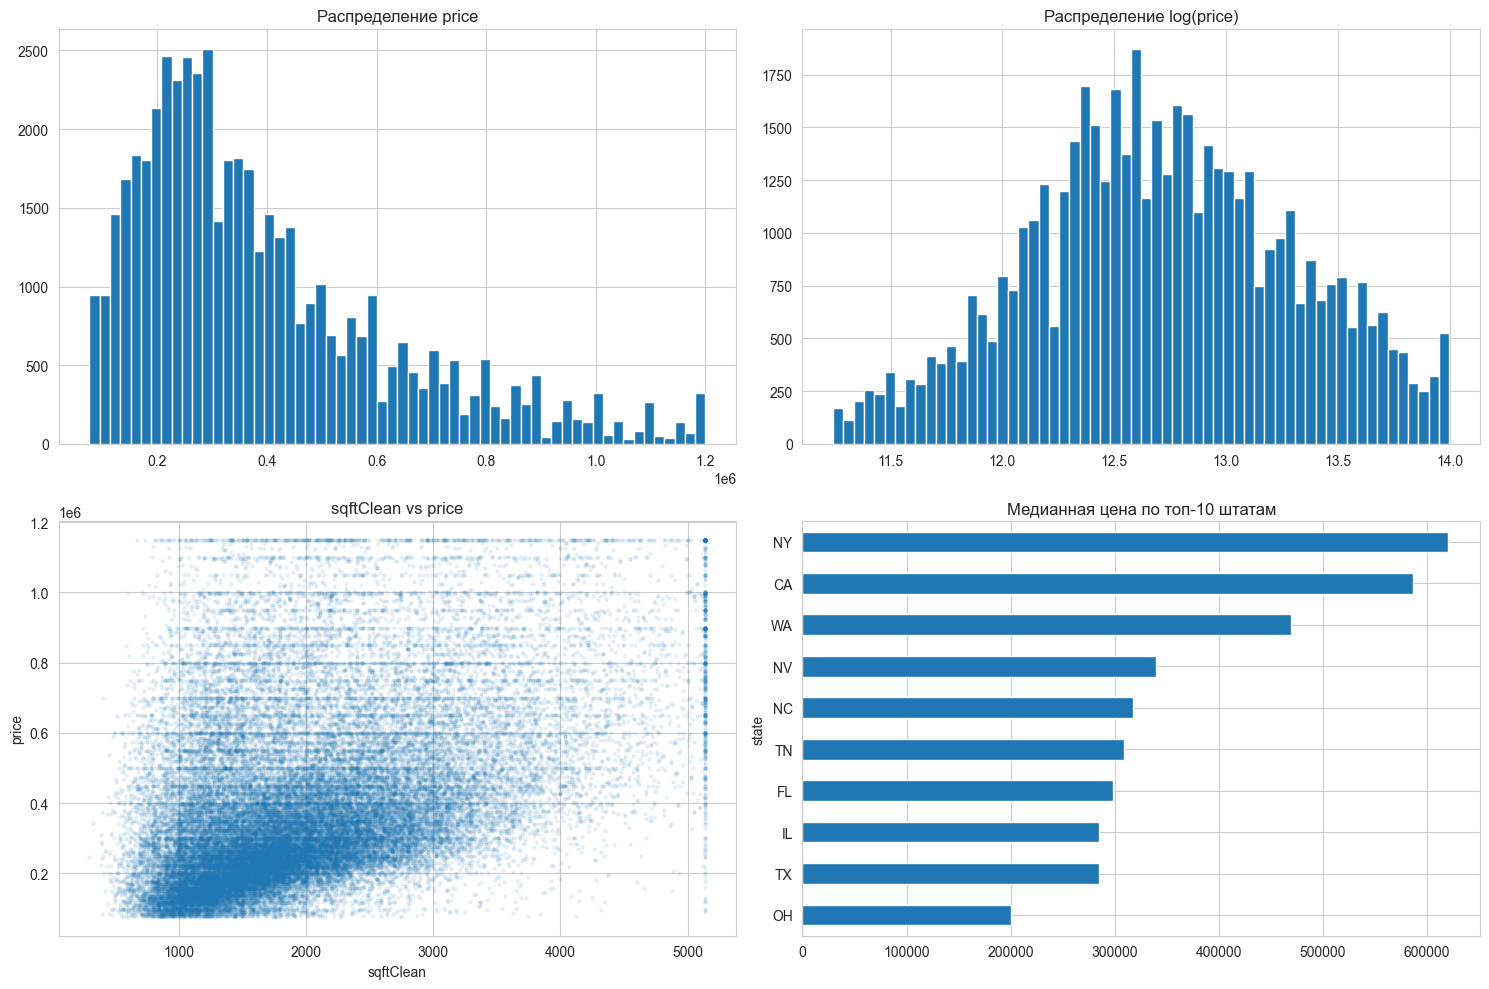

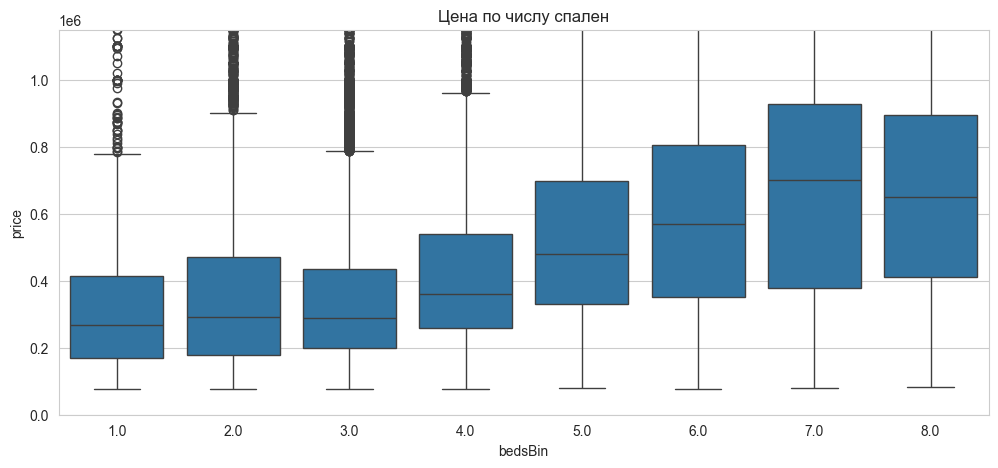

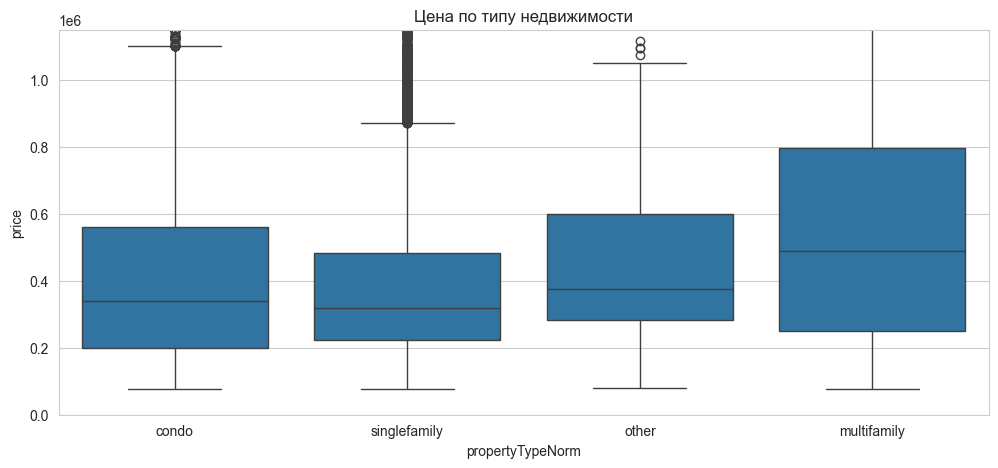

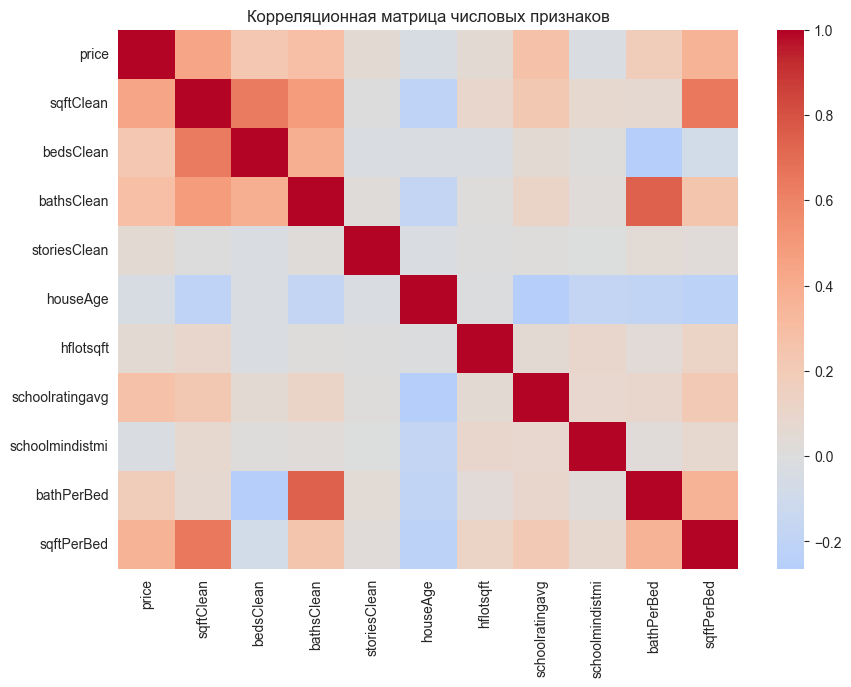

In [19]:
eda = df_core.sample(min(len(df_core), 50_000), random_state=RANDOM_STATE).copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(eda["price"], bins=60, edgecolor="white")
axes[0, 0].set_title("Распределение price")

axes[0, 1].hist(eda["logPrice"], bins=60, edgecolor="white")
axes[0, 1].set_title("Распределение log(price)")

x = eda["sqftClean"].clip(upper=eda["sqftClean"].quantile(0.99))
y = eda["price"].clip(upper=eda["price"].quantile(0.99))
axes[1, 0].scatter(x, y, s=5, alpha=0.08)
axes[1, 0].set_title("sqftClean vs price")
axes[1, 0].set_xlabel("sqftClean")
axes[1, 0].set_ylabel("price")

top_states = eda["state"].astype(str).value_counts().head(10).index
(
    eda.loc[eda["state"].isin(top_states)]
    .groupby("state")["price"]
    .median()
    .sort_values()
    .plot(kind="barh", ax=axes[1, 1]))
axes[1, 1].set_title("Медианная цена по топ-10 штатам")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=eda.assign(bedsBin=eda["bedsClean"].clip(upper=8)),
    x="bedsBin",
    y="price")
plt.ylim(0, eda["price"].quantile(0.99))
plt.title("Цена по числу спален")
plt.show()

plt.figure(figsize=(12, 5))
top_pt = eda["propertyTypeNorm"].value_counts().head(5).index
sns.boxplot(
    data=eda.loc[eda["propertyTypeNorm"].isin(top_pt)],
    x="propertyTypeNorm",
    y="price")
plt.ylim(0, eda["price"].quantile(0.99))
plt.title("Цена по типу недвижимости")
plt.show()

corr_cols = [
    "price", "sqftClean", "bedsClean", "bathsClean", "storiesClean",
    "houseAge", "hflotsqft", "schoolratingavg", "schoolmindistmi",
    "bathPerBed", "sqftPerBed"]
corr_cols = [c for c in corr_cols if c in eda.columns]
corr = eda[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица числовых признаков")
plt.show()


### Вывод

EDA показывает:
- сильную асимметрию распределения цены
- выраженную связь цены и площади
- заметное влияние географии и типа объекта
- неоднородность между сегментами рынка

Это делает логарифмирование таргета и применение нелинейных моделей оправданными


## 6. Статистическое обоснование части признаков

После визуального анализа полезно формально проверить несколько гипотез

Ниже используются компактные статистические тесты, которые помогают подтвердить полезность части признаков

Расчёт коэффициента корреляции Спирмена для sqftClean и houseAge, тест Манна-Уитни для сравнения цен между группами с бассейном и без, а также между объектами с высоким и низким рейтингом школ


In [20]:
stat_df = eda.copy()

corr_sqft, p_sqft = spearmanr(
    stat_df["sqftClean"].fillna(stat_df["sqftClean"].median()),
    stat_df["price"])

corr_age, p_age = spearmanr(
    stat_df["houseAge"].fillna(stat_df["houseAge"].median()),
    stat_df["price"])

pool_yes = stat_df.loc[stat_df["hasPoolUnified"] == 1, "price"].dropna()
pool_no = stat_df.loc[stat_df["hasPoolUnified"] == 0, "price"].dropna()
if len(pool_yes) > 0 and len(pool_no) > 0:
    u_pool, p_pool = mannwhitneyu(pool_yes, pool_no, alternative="two-sided")
    median_diff_pool = pool_yes.median() - pool_no.median()
else:
    u_pool, p_pool, median_diff_pool = np.nan, np.nan, np.nan

high_school = stat_df.loc[stat_df["schoolratingavg"] >= 8, "price"].dropna()
low_school = stat_df.loc[stat_df["schoolratingavg"] < 8, "price"].dropna()
if len(high_school) > 0 and len(low_school) > 0:
    u_school, p_school = mannwhitneyu(high_school, low_school, alternative="two-sided")
    median_diff_school = high_school.median() - low_school.median()
else:
    u_school, p_school, median_diff_school = np.nan, np.nan, np.nan

stats_table = pd.DataFrame({
    "hypothesis": [
        "Spearman: sqft and price",
        "Spearman: houseAge and price",
        "Mann-Whitney: hasPoolUnified vs noPool",
        "Mann-Whitney: schoolratingavg >= 8 vs < 8",
    ],
    "statistic": [corr_sqft, corr_age, u_pool, u_school],
    "p_value": [p_sqft, p_age, p_pool, p_school],
    "effect_size": [corr_sqft, corr_age, median_diff_pool, median_diff_school]})
display(stats_table)


,hypothesis,statistic,p_value,effect_size
0,Spearman: sqft and price,4.595407e-01,0.000000e+00,0.459541
1,Spearman: houseAge and price,-1.304113e-01,1.597963e-188,-0.130411
2,Mann-Whitney: hasPoolUnified vs noPool,1.869568e+08,2.740413e-191,84100.000000
3,Mann-Whitney: schoolratingavg >= 8 vs < 8,1.415764e+08,0.000000e+00,128952.000000


### Вывод

На большой выборке p-value почти всегда очень мал, поэтому основной акцент делается не на формальной значимости, а на величине эффекта и предметной интерпретации.

Статистический блок подтверждает полезность таких групп признаков, как:
- площадь
- возраст дома
- признаки бассейна
- школьные признаки

они должны быть включены в модель

## 7. Географические OOF-признаки

Чтобы не перегружать код, в финальной версии используется компактный набор OOF-признаков по zipcode:
- медиана цены
- медиана цены за квадратный фут
- логарифм количества объектов

Эти признаки дают модели локальный рыночный контекст без утечки таргета

In [21]:
def add_zip_oof_features(df_in, y_raw, n_splits=N_SPLITS):
    out = df_in.copy().reset_index(drop=True)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    global_med = float(np.nanmedian(y_raw))
    global_pps = float(np.nanmedian(y_raw / np.clip(df_in["sqftClean"].values.astype(float), 1, None)))

    out["zip_med"] = np.nan
    out["zip_cnt"] = 0.0
    out["zip_pps"] = np.nan

    for tr_idx, va_idx in kf.split(df_in):
        tr = df_in.iloc[tr_idx].copy()
        tr["_y"] = y_raw[tr_idx]
        tr["_pps"] = y_raw[tr_idx] / np.clip(df_in.iloc[tr_idx]["sqftClean"].values.astype(float), 1, None)

        grp = tr.groupby("zipcode").agg(
            _med=("_y", "median"),
            _cnt=("_y", "size"),
            _pps=("_pps", "median")).reset_index()

        va = df_in.iloc[va_idx][["zipcode"]].merge(grp, on="zipcode", how="left")
        out.iloc[va_idx, out.columns.get_loc("zip_med")] = va["_med"].fillna(global_med).values
        out.iloc[va_idx, out.columns.get_loc("zip_cnt")] = va["_cnt"].fillna(0).values
        out.iloc[va_idx, out.columns.get_loc("zip_pps")] = va["_pps"].fillna(global_pps).values

    out["zip_med"] = out["zip_med"].fillna(global_med)
    out["zip_pps"] = out["zip_pps"].fillna(global_pps)
    out["zip_cntlog"] = np.log1p(out["zip_cnt"])
    out = out.drop(columns=["zip_cnt"])
    return out

df_model = add_zip_oof_features(df_core, df_core["price"].values, N_SPLITS)
display(df_model[["zipcode", "zip_med", "zip_pps", "zip_cntlog"]].head())

,zipcode,zip_med,zip_pps,zip_cntlog
0,28387,348499.0,142.716142,4.127134
1,99216,298420.5,167.642765,2.564949
2,19145,252000.0,206.748911,4.770685
3,50401,155000.0,121.356275,3.178054
4,77080,329900.0,167.164762,5.799093


### Вывод

Даже компактные OOF geo-признаки дают модели сильный локальный контекст:
- средний уровень цен в ZIP
- локальную цену за квадратный фут
- плотность наблюдений

Для рынка недвижимости это особенно важно, потому что одинаковые дома в разных локациях могут сильно отличаться по цене

## 8. Подготовка признаков и CV-функции

Ниже задаются:
- два набора признаков: контрольный и усиленный (featurepack -  набор с дополнительными флагами пропусков и объединёнными признаками для проверки важности "деталей")
- функции для baseline-моделей
- функции для CatBoost и LightGBM
- единая схема расчёта метрик и таблиц результатов


In [22]:
CONTROL_BASE_NUM = [
    "sqftClean", "logSqft", "bedsClean", "bathsClean", "storiesClean",
    "bathPerBed", "sqftPerBed", "sqftPerBath", "totalRooms",
    "hfyearbuilt", "houseAge", "isMissingYear", "hfremodeledyear",
    "hfyearsSinceReno", "hfwasRemodeled", "isNewBuild", "isHistoric",
    "hflotsqft", "hflogLotsqft", "lotPerRoom", "isMissingLot",
    "hfhascentralac", "hfhasforcedair", "hfparkingspaces",
    "hfhasgarage", "hfhasfireplace", "hfhaspool", "hfhascarport",
    "schoolratingavg", "schoolratingmax", "schoolratingcount",
    "schoolmindistmi", "schoolhashighschool", "isMissingSchoolRating",
    "zip_med", "zip_pps", "zip_cntlog"]

# заменяем редко заполненный hfparkingspaces на бинарный hfparkinginfo, который покрывает 100% объектов
# hasPoolUnified объединяет данные из трёх разных колонок о бассейне
# явно указываем на информативные пропуски isMissingSchoolDist и isMissingReno, что позволяют модели учитывать сам факт отсутствия данных

FEATURE_PACK_NUM = [
    "sqftClean", "logSqft", "bedsClean", "bathsClean", "storiesClean",
    "bathPerBed", "sqftPerBed", "sqftPerBath", "totalRooms",
    "hfyearbuilt", "houseAge", "isMissingYear", "hfremodeledyear",
    "hfyearsSinceReno", "hfwasRemodeled", "isNewBuild", "isHistoric",
    "hflotsqft", "hflogLotsqft", "lotPerRoom", "isMissingLot",
    "hfhascentralac", "hfhasforcedair", "hfparkinginfo",
    "hfhasgarage", "hfhasfireplace", "hasPoolUnified", "hfhascarport",
    "schoolratingavg", "schoolratingmax", "schoolratingcount",
    "schoolmindistmi", "schoolhashighschool", "isMissingSchoolRating",
    "isMissingSchoolDist", "isMissingReno",
    "zip_med", "zip_pps", "zip_cntlog"]

CAT_FEATURES = [c for c in ["state", "city", "zipcode", "propertyTypeNorm", "zipPrefix3"] if c in df_model.columns]
TARGET_COL = "price"

CONTROL_NUM_FEATURES = [c for c in CONTROL_BASE_NUM if c in df_model.columns]
FEATURE_PACK_NUM_FEATURES = [c for c in FEATURE_PACK_NUM if c in df_model.columns]

# в данных могут встречаться объекты с ценой 0
def mape_pct(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true > 0
    return float(mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100)

def mae_abs(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def _split_iterator(X, groups=None):
    if groups is None:
        cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        return list(cv.split(X))
    cv = GroupKFold(n_splits=N_SPLITS)
    return list(cv.split(X, groups=groups))

def make_ridge_pipeline(num_features, cat_features, alpha=3.0):
    ridge_cat = [c for c in cat_features if c in {"state", "propertyTypeNorm", "zipPrefix3"}]
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]), ridge_cat),
        ])
    model = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    return Pipeline([
        ("prep", preprocessor),
        ("model", model)])

# глобальная медиана
def run_dummy_median_cv(df_in, tag="DummyMedian"):
    y = df_in[TARGET_COL].values
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y), dtype=float)
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(df_in), 1):
        model = DummyRegressor(strategy="median")
        model.fit(np.zeros((len(tr_idx), 1)), y[tr_idx])
        pred = model.predict(np.zeros((len(va_idx), 1)))
        oof[va_idx] = pred
        fold_rows.append({"model": tag, "fold": fold, "mape": mape_pct(y[va_idx], pred), "mae": mae_abs(y[va_idx], pred)})

    folds_df = pd.DataFrame(fold_rows)
    summary = {
        "model": tag,
        "mean_mape": float(folds_df["mape"].mean()),
        "std_mape": float(folds_df["mape"].std(ddof=1)),
        "mean_mae": float(folds_df["mae"].mean()),
        "std_mae": float(folds_df["mae"].std(ddof=1)),
        "MAPE": mape_pct(y, oof),
        "MAE": mae_abs(y, oof),
        "avg_best_iteration": np.nan}
    return summary, folds_df, oof

# медиана по zipcode
def run_geo_median_cv(df_in, geo_col="zipcode", tag="GeoMedianZipcode"):
    y = df_in[TARGET_COL].values
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y), dtype=float)
    global_median = float(np.median(y))
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(df_in), 1):
        tr = df_in.iloc[tr_idx].copy()
        va = df_in.iloc[va_idx].copy()
        tr["_y"] = y[tr_idx]
        med_map = tr.groupby(geo_col)["_y"].median()
        pred = va[geo_col].map(med_map).fillna(global_median).values
        oof[va_idx] = pred
        fold_rows.append({"model": tag, "fold": fold, "mape": mape_pct(y[va_idx], pred), "mae": mae_abs(y[va_idx], pred)})

    folds_df = pd.DataFrame(fold_rows)
    summary = {
        "model": tag,
        "mean_mape": float(folds_df["mape"].mean()),
        "std_mape": float(folds_df["mape"].std(ddof=1)),
        "mean_mae": float(folds_df["mae"].mean()),
        "std_mae": float(folds_df["mae"].std(ddof=1)),
        "MAPE": mape_pct(y, oof),
        "MAE": mae_abs(y, oof),
        "avg_best_iteration": np.nan}
    return summary, folds_df, oof

# линейная Ridge на логарифме цены
def run_ridge_log_cv(df_in, num_features, cat_features, tag="RidgeLog"):
    X = df_in[num_features + cat_features].copy()
    y_raw = df_in[TARGET_COL].values
    y_log = np.log1p(y_raw)

    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof_raw = np.zeros(len(X), dtype=float)
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X), 1):
        Xtr = X.iloc[tr_idx].copy()
        Xva = X.iloc[va_idx].copy()
        ytr_log = y_log[tr_idx]
        yva_raw = y_raw[va_idx]

        pipe = make_ridge_pipeline(num_features, cat_features, alpha=3.0)
        pipe.fit(Xtr, ytr_log)
        pred_log = pipe.predict(Xva)
        pred_raw = np.expm1(np.clip(pred_log, -20, 20))
        oof_raw[va_idx] = pred_raw

        fold_rows.append({"model": tag, "fold": fold, "mape": mape_pct(yva_raw, pred_raw), "mae": mae_abs(yva_raw, pred_raw)})

    folds_df = pd.DataFrame(fold_rows)
    summary = {
        "model": tag,
        "mean_mape": float(folds_df["mape"].mean()),
        "std_mape": float(folds_df["mape"].std(ddof=1)),
        "mean_mae": float(folds_df["mae"].mean()),
        "std_mae": float(folds_df["mae"].std(ddof=1)),
        "MAPE": mape_pct(y_raw, oof_raw),
        "MAE": mae_abs(y_raw, oof_raw),
        "avg_best_iteration": np.nan}
    return summary, folds_df, oof_raw

# градиентный бустинг с логарифмированием таргета и встроенной ранней остановкой
def run_catboost_cv(df_in, num_features, cat_features, iterations=3000, tag="CatBoost"):
    X = df_in[num_features + cat_features].copy()
    y_raw = df_in[TARGET_COL].values
    y_log = np.log1p(y_raw)

    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof_raw = np.zeros(len(X), dtype=float)
    fold_rows = []
    importances = []

    cat_cols_local = [c for c in cat_features if c in X.columns]
    num_cols_local = [c for c in num_features if c in X.columns]

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X), 1):
        Xtr = X.iloc[tr_idx].copy()
        Xva = X.iloc[va_idx].copy()
        ytr_log = y_log[tr_idx]
        yva_raw = y_raw[va_idx]

        medians = Xtr[num_cols_local].median(numeric_only=True)
        Xtr[num_cols_local] = Xtr[num_cols_local].fillna(medians)
        Xva[num_cols_local] = Xva[num_cols_local].fillna(medians)

        for c in cat_cols_local:
            Xtr[c] = Xtr[c].fillna("__nan__").astype(str).astype(object)
            Xva[c] = Xva[c].fillna("__nan__").astype(str).astype(object)

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            depth=8,
            learning_rate=0.05,
            iterations=iterations,
            random_seed=RANDOM_STATE,
            verbose=False)
        model.fit(
            Xtr, ytr_log,
            cat_features=cat_cols_local,
            eval_set=(Xva, np.log1p(yva_raw)),
            use_best_model=True,
            verbose=False,
            early_stopping_rounds=200)

        pred_log = model.predict(Xva)
        pred_raw = np.expm1(np.clip(pred_log, -20, 20))
        oof_raw[va_idx] = pred_raw

        fold_rows.append({
            "model": tag,
            "fold": fold,
            "mape": mape_pct(yva_raw, pred_raw),
            "mae": mae_abs(yva_raw, pred_raw),
            "best_iteration": int(model.get_best_iteration()) if model.get_best_iteration() is not None else np.nan})

        importances.append(pd.DataFrame({
            "feature": X.columns,
            "importance": model.get_feature_importance(type="FeatureImportance")}))

    folds_df = pd.DataFrame(fold_rows)
    imp_df = (
        pd.concat(importances, axis=0)
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True))

    summary = {
        "model": tag,
        "mean_mape": float(folds_df["mape"].mean()),
        "std_mape": float(folds_df["mape"].std(ddof=1)),
        "mean_mae": float(folds_df["mae"].mean()),
        "std_mae": float(folds_df["mae"].std(ddof=1)),
        "MAPE": mape_pct(y_raw, oof_raw),
        "MAE": mae_abs(y_raw, oof_raw),
        "avg_best_iteration": float(folds_df["best_iteration"].mean())}
    return summary, folds_df, imp_df, oof_raw

# используется предварительно оптимизированный набор 
# (здесь не буду вставлять оптимизацию для сокращения кода/времени)
LGBM_PARAMS_STRONG = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.01402,
    n_estimators=40000,
    num_leaves=430,
    min_child_samples=15,
    subsample=0.896,
    colsample_bytree=0.774,
    reg_alpha=0.152,
    reg_lambda=0.134,
    min_split_gain=0.0,
    random_state=RANDOM_STATE,
    verbose=-1)

def run_lgbm_cv(df_in, num_features, cat_features, groups=None, tag="LightGBM"):
    X = df_in[num_features + cat_features].copy()
    y_raw = df_in[TARGET_COL].values
    y_log = np.log1p(y_raw)

    split_iter = _split_iterator(X, groups=groups)
    oof_raw = np.zeros(len(X), dtype=float)
    fold_rows = []
    fold_importances = []

    params = dict(LGBM_PARAMS_STRONG)

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        Xtr = X.iloc[tr_idx].copy()
        Xva = X.iloc[va_idx].copy()
        ytr_log = y_log[tr_idx]
        yva_raw = y_raw[va_idx]
        yva_log = y_log[va_idx]

        num_cols_local = [c for c in num_features if c in Xtr.columns]
        cat_cols_local = [c for c in cat_features if c in Xtr.columns]

        medians = Xtr[num_cols_local].median(numeric_only=True)
        Xtr[num_cols_local] = Xtr[num_cols_local].fillna(medians)
        Xva[num_cols_local] = Xva[num_cols_local].fillna(medians)

        for c in cat_cols_local:
            Xtr[c] = Xtr[c].fillna("unknown").astype(str).astype("category")
            Xva[c] = Xva[c].fillna("unknown").astype(str).astype("category")

        model = lgb.LGBMRegressor(**params)
        model.fit(
            Xtr, ytr_log,
            eval_set=[(Xva, yva_log)],
            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

        pred_log = model.predict(Xva)
        pred_raw = np.expm1(np.clip(pred_log, -20, 20))
        oof_raw[va_idx] = pred_raw

        fold_rows.append({
            "model": tag,
            "fold": fold,
            "mape": mape_pct(yva_raw, pred_raw),
            "mae": mae_abs(yva_raw, pred_raw),
            "best_iteration": int(getattr(model, "best_iteration_", params["n_estimators"]))})

        fi = pd.DataFrame({
            "feature": X.columns,
            "importance": model.booster_.feature_importance(importance_type="gain")})
        fold_importances.append(fi)

    folds_df = pd.DataFrame(fold_rows)
    imp_df = (
        pd.concat(fold_importances, axis=0)
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True))

    summary = {
        "model": tag,
        "mean_mape": float(folds_df["mape"].mean()),
        "std_mape": float(folds_df["mape"].std(ddof=1)),
        "mean_mae": float(folds_df["mae"].mean()),
        "std_mae": float(folds_df["mae"].std(ddof=1)),
        "MAPE": mape_pct(y_raw, oof_raw),
        "MAE": mae_abs(y_raw, oof_raw),
        "avg_best_iteration": float(folds_df["best_iteration"].mean())}
    return summary, folds_df, imp_df, oof_raw

print("CONTROL_NUM_FEATURES:", len(CONTROL_NUM_FEATURES))
print("FEATURE_PACK_NUM_FEATURES:", len(FEATURE_PACK_NUM_FEATURES))
print("CAT_FEATURES:", CAT_FEATURES)

CONTROL_NUM_FEATURES: 37
FEATURE_PACK_NUM_FEATURES: 39
CAT_FEATURES: ['state', 'city', 'zipcode', 'propertyTypeNorm', 'zipPrefix3']


Подготовлены:
- контрольный набор признаков;
- усиленный набор `featurepack`;
- baseline-модели;
- функции для CatBoost и LightGBM.

Теперь можно переходить к экспериментам и сравнительному анализу.


## 9. Baseline-модели

Сначала фиксируем точку отсчёта:
- глобальная медиана
- медиана по zipcode
- линейная модель RidgeLog

Это нужно, чтобы потом честно показать превосходство более сильных нелинейных методов


In [23]:
baseline_results = []
baseline_fold_tables = {}
baseline_oof = {}

for summ, folds, oof in [
    run_dummy_median_cv(df_model, tag="DummyMedian"),
    run_geo_median_cv(df_model, geo_col="zipcode", tag="GeoMedianZipcode"),
    run_ridge_log_cv(df_model, CONTROL_NUM_FEATURES, CAT_FEATURES, tag="RidgeLog"),
]:
    baseline_results.append(summ)
    baseline_fold_tables[summ["model"]] = folds
    baseline_oof[summ["model"]] = oof

baseline_df = pd.DataFrame(baseline_results).sort_values("MAPE").reset_index(drop=True)
display(baseline_df)

,model,mean_mape,std_mape,mean_mae,std_mae,MAPE,MAE,avg_best_iteration
0,RidgeLog,21.487886,1.101794,84007.134299,4679.031473,21.487890,84007.149270,NaN
1,GeoMedianZipcode,33.685653,0.042122,119174.232132,654.311725,33.685653,119174.232612,NaN
2,DummyMedian,52.631440,0.261844,177998.610577,491.479312,52.631441,177998.611665,NaN


### Вывод по baseline

Baseline-модели задают корректную отправную точку:
- глобальная медиана - самый простой ориентир
- географическая медиана уже заметно сильнее
- линейная модель улучшает baseline, но оставляет пространство для дальнейшего прироста качества

Это означает, что задача действительно требует более сильных нелинейных моделей


## 10. Сравнение моделей в одинаковых условиях

После baseline добавляем современные модели в такой же схеме кросс-валидации, чтобы сравнение было честным
На этом этапе важно не максимальное качество, а корректный ответ на вопрос:

какая модель лучше решает задачу в одинаковых условиях эксперимента?

Ниже сравниваются baseline-модели, CatBoost и контрольная версия LightGBM без усиленного feature pack

In [24]:
same_results = baseline_results.copy()
fold_tables = {}
importance_tables = {}
oof_store = {}

for k, v in baseline_fold_tables.items():
    fold_tables[k] = v
for k, v in baseline_oof.items():
    oof_store[k] = v

# CatBoost
for iterations, tag in [
    (3000, "CatBoost_control"),
    (8000, "CatBoost_long"),
]:
    summ, folds, imp, oof = run_catboost_cv(
        df_model,
        num_features=CONTROL_NUM_FEATURES,
        cat_features=CAT_FEATURES,
        iterations=iterations,
        tag=tag)
    same_results.append(summ)
    fold_tables[tag] = folds
    importance_tables[tag] = imp
    oof_store[tag] = oof

# LightGBM 
summ, folds, imp, oof = run_lgbm_cv(
    df_model,
    num_features=CONTROL_NUM_FEATURES,
    cat_features=CAT_FEATURES,
    groups=None,
    tag="LightGBM_control")
same_results.append(summ)
fold_tables[summ["model"]] = folds
importance_tables[summ["model"]] = imp
oof_store[summ["model"]] = oof

same_conditions_df = pd.DataFrame(same_results).sort_values("MAPE").reset_index(drop=True)
display(same_conditions_df)

,model,mean_mape,std_mape,mean_mae,std_mae,MAPE,MAE,avg_best_iteration
0,LightGBM_control,12.072920,0.038163,45803.303698,368.247057,12.072920,45803.301681,24551.4
1,CatBoost_long,13.984167,0.058881,53514.299924,414.899280,13.984166,53514.297653,7997.8
2,CatBoost_control,14.708005,0.073731,56261.658340,507.767688,14.708005,56261.655948,2999.0
3,RidgeLog,21.487886,1.101794,84007.134299,4679.031473,21.487890,84007.149270,NaN
4,GeoMedianZipcode,33.685653,0.042122,119174.232132,654.311725,33.685653,119174.232612,NaN
5,DummyMedian,52.631440,0.261844,177998.610577,491.479312,52.631441,177998.611665,NaN


### Вывод по сравнению моделей в одинаковых условиях

Сравнение проведено корректно:
- baseline задаёт отправную точку
- CatBoost показывает, что современные нелинейные методы действительно улучшают качество 
- контрольная версия LightGBM позволяет честно проверить, даёт ли этот алгоритм дополнительный выигрыш

LightGBM показал лучший результат, посмотрим как его можно дополнительно усилить.

## 11. Усиление LightGBM: пробуем улучшить качество предсказания

После честного сравнения контрольной версии LightGBM пробуем улучшить качество не сменой алгоритма, а за счёт более богатого признакового пространства.

Идея этого шага:
- оставить тот же класс модели
- усилить качество сигнала на входе
- проверить, даёт ли feature engineering реальный прирост качества

Ниже строится версия LightGBM_featurepack, а затем она сравнивается с контрольной версией LightGBM_control

In [25]:
lgb_featurepack_summary, lgb_featurepack_folds, lgb_featurepack_imp, lgb_featurepack_oof = run_lgbm_cv(
    df_model,
    num_features=FEATURE_PACK_NUM_FEATURES,
    cat_features=CAT_FEATURES,
    groups=None,
    tag="LightGBM_featurepack")

fold_tables[lgb_featurepack_summary["model"]] = lgb_featurepack_folds
importance_tables[lgb_featurepack_summary["model"]] = lgb_featurepack_imp
oof_store[lgb_featurepack_summary["model"]] = lgb_featurepack_oof

lgb_compare_df = pd.DataFrame([
    same_conditions_df.loc[same_conditions_df["model"] == "LightGBM_control"].iloc[0].to_dict(),
    lgb_featurepack_summary]).sort_values("MAPE").reset_index(drop=True)

display(lgb_compare_df)
display(lgb_featurepack_imp.head(20))

,model,mean_mape,std_mape,mean_mae,std_mae,MAPE,MAE,avg_best_iteration
0,LightGBM_featurepack,11.993587,0.042006,45478.646611,425.493279,11.993587,45478.644641,26553.6
1,LightGBM_control,12.072920,0.038163,45803.303698,368.247057,12.072920,45803.301681,24551.4


,feature,importance
0,zip_med,727395.225656
1,sqftClean,503012.597834
2,zip_pps,350339.559171
3,zipcode,113771.260807
4,logSqft,66260.128085
5,hfyearbuilt,48408.541908
6,city,44550.874033
7,bathsClean,44103.819648
8,zipPrefix3,34054.039167
9,sqftPerBed,27480.443672


### Вывод по усилению LightGBM

Контрольная версия LightGBM_control уже показывает отличный результат, но эксперимент с LightGBM_featurepack показывает дополнительный прирост качества, улучшение достигается не сменой алгоритма, а усилением признакового пространства


## 12. Финальная таблица сравнения моделей

Объединяем результаты всех ключевых моделей в одну итоговую таблицу

In [26]:
final_results = baseline_results.copy()

for model_name in ["CatBoost_control", "CatBoost_long", "LightGBM_control"]:
    row = same_conditions_df.loc[same_conditions_df["model"] == model_name].iloc[0].to_dict()
    final_results.append(row)

final_results.append(lgb_featurepack_summary)

results_df = pd.DataFrame(final_results).sort_values("MAPE").reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
print("Winner:", best_model_name)
results_df.to_csv(OUTDIR / "final_model_comparison.csv", index=False)
print("Saved:", OUTDIR / "final_model_comparison.csv")

,model,mean_mape,std_mape,mean_mae,std_mae,MAPE,MAE,avg_best_iteration
0,LightGBM_featurepack,11.993587,0.042006,45478.646611,425.493279,11.993587,45478.644641,26553.6
1,LightGBM_control,12.072920,0.038163,45803.303698,368.247057,12.072920,45803.301681,24551.4
2,CatBoost_long,13.984167,0.058881,53514.299924,414.899280,13.984166,53514.297653,7997.8
3,CatBoost_control,14.708005,0.073731,56261.658340,507.767688,14.708005,56261.655948,2999.0
4,RidgeLog,21.487886,1.101794,84007.134299,4679.031473,21.487890,84007.149270,NaN
5,GeoMedianZipcode,33.685653,0.042122,119174.232132,654.311725,33.685653,119174.232612,NaN
6,DummyMedian,52.631440,0.261844,177998.610577,491.479312,52.631441,177998.611665,NaN


Winner: LightGBM_featurepack
Saved: output\final_model_comparison.csv


### Итоговый вывод по сравнению моделей

Финальная таблица позволяет сделать главный практический вывод проекта:

- baseline-модели задают отправную точку
- CatBoost подтверждает, что задача требует современных нелинейных методов
- контрольная версия LightGBM показывает сильный уровень качества
- усиленная версия LightGBM_featurepack даёт лучший результат и становится финальным кандидатом на production

## 13. Проверка устойчивости победителя

После выбора лучшей модели полезно проверить, насколько её качество устойчиво:
- при более жёсткой географической схеме валидации
- по распределению ошибок на разных ценовых сегментах

Ниже используются GroupKFold и анализ остатков для проверки надёжности победителя

,model,fold,mape,mae,best_iteration
0,LightGBM_featurepack_GroupKFold,1,20.534536,85641.083521,489
1,LightGBM_featurepack_GroupKFold,2,18.774674,80661.571651,267
2,LightGBM_featurepack_GroupKFold,3,19.707974,66368.211298,412
3,LightGBM_featurepack_GroupKFold,4,17.774503,69148.287331,404
4,LightGBM_featurepack_GroupKFold,5,17.324626,66773.566680,732


{'model': 'LightGBM_featurepack_GroupKFold',
 'mean_mape': 18.82326264087282,
 'std_mape': 1.328471035228612,
 'mean_mae': 73718.54409623204,
 'std_mae': 8852.96459389627,
 'MAPE': 18.82327434830429,
 'MAE': 73718.59701842527,
 'avg_best_iteration': 460.8}

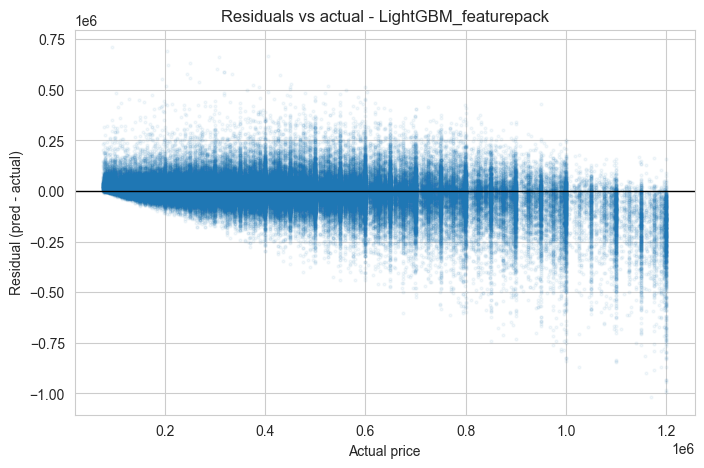

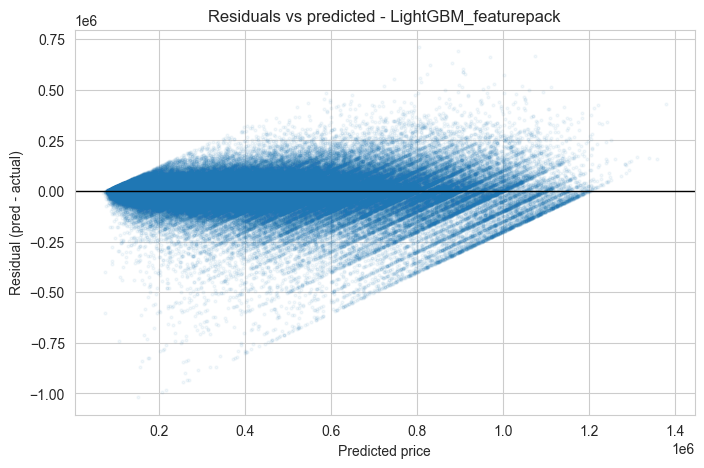

,price_bin,n,mean_price,mape,mae
0,"(76249.999, 153000.0]",21798,119915.012386,21.415606,24018.948177
1,"(153000.0, 199900.0]",22403,178309.452886,12.412824,22062.490820
2,"(199900.0, 239900.0]",21308,221566.988173,10.068611,22258.617437
3,"(239900.0, 279900.0]",21978,260182.387751,10.055880,26162.712134
4,"(279900.0, 325000.0]",21355,302628.666495,10.141784,30705.827519
5,"(325000.0, 380000.0]",21858,353321.438695,10.043256,35498.955769
6,"(380000.0, 454900.0]",21640,416710.892560,10.726939,44754.794053
7,"(454900.0, 569900.0]",21767,508255.198787,11.106658,56451.673110
8,"(569900.0, 749900.0]",21771,651377.363006,11.315779,73654.494711
9,"(749900.0, 1200000.0]",21710,931582.985905,12.568398,119577.023038


Saved: output\error_by_price_bin.csv


In [27]:
group_summary, group_folds, _, group_oof = run_lgbm_cv(
    df_model,
    num_features=FEATURE_PACK_NUM_FEATURES,
    cat_features=CAT_FEATURES,
    groups=df_model["zipPrefix3"].values,
    tag="LightGBM_featurepack_GroupKFold")
display(group_folds)
display(group_summary)

best_oof = lgb_featurepack_oof
tmp_err = pd.DataFrame({"y": df_model[TARGET_COL].values, "pred": best_oof})
tmp_err["residual"] = tmp_err["pred"] - tmp_err["y"]
tmp_err["ape"] = np.abs(tmp_err["pred"] - tmp_err["y"]) / tmp_err["y"]

plt.figure(figsize=(8, 5))
plt.scatter(tmp_err["y"], tmp_err["residual"], s=4, alpha=0.05)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Actual price")
plt.ylabel("Residual (pred - actual)")
plt.title("Residuals vs actual - LightGBM_featurepack")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(tmp_err["pred"], tmp_err["residual"], s=4, alpha=0.05)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Predicted price")
plt.ylabel("Residual (pred - actual)")
plt.title("Residuals vs predicted - LightGBM_featurepack")
plt.show()

tmp_err["price_bin"] = pd.qcut(tmp_err["y"], q=10, duplicates="drop")
error_by_bin = (tmp_err.groupby("price_bin").agg(n=("y", "size"), mean_price=("y", "mean"), mape=("ape", lambda x: float(np.mean(x) * 100))).reset_index())
error_by_bin["mae"] = (tmp_err.groupby("price_bin").apply(lambda g: float(np.mean(np.abs(g["pred"] - g["y"])))).values)
display(error_by_bin)
error_by_bin.to_csv(OUTDIR / "error_by_price_bin.csv", index=False)
print("Saved:", OUTDIR / "error_by_price_bin.csv")

### Вывод

GroupKFold даёт более жёсткую оценку, чем обычная 5-fold CV, что ожидаемо для рынка недвижимости.  
Этот результат не заменяет основной скор, а дополняет его: модель сильна на стандартной схеме валидации, но перенос на новые географические кластеры заметно сложнее

Анализ остатков показывает, в каких ценовых диапазонах модель ошибается сильнее и нет ли систематического перекоса в сторону завышения или занижения прогноза


## 14. Финальное обучение, bundle и пример для заказчика

После выбора лучшей модели обучаем её на всей рабочей выборке и сохраняем production-ready bundle

Bundle включает:
- саму модель
- список признаков
- статистики для заполнения пропусков
- географические lookup-таблицы
- reference year для воспроизводимого инференса

В реальном внедрении пользовательский интерфейс обычно выносится в отдельное приложение, однако для демонстрации заказчику базовый сценарий можно показать и прямо в ноутбуке

In [28]:
def _safe_mode(series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if len(mode_vals) else "unknown"

def build_zip_geo_maps(df_train):
    global_med = float(df_train["price"].median())
    global_pps = float(np.nanmedian(df_train["price"].values / np.clip(df_train["sqftClean"].values.astype(float), 1, None)))
    tmp = df_train[["zipcode", "price", "sqftClean"]].copy()
    tmp["pps"] = tmp["price"] / np.clip(tmp["sqftClean"].astype(float), 1, None)
    med_map = df_train.groupby("zipcode")["price"].median()
    pps_map = tmp.groupby("zipcode")["pps"].median()
    cnt_map = df_train.groupby("zipcode")["price"].size()
    return {
        "zip_med_map": med_map.to_dict(),
        "zip_pps_map": pps_map.to_dict(),
        "zip_cnt_map": cnt_map.to_dict(),
        "zip_med_default": global_med,
        "zip_pps_default": global_pps}

def prepare_lgbm_frame_final(X, num_features, cat_features, num_medians, cat_modes):
    Xp = X.copy()
    for c in num_features:
        if c not in Xp.columns:
            Xp[c] = np.nan
        Xp[c] = pd.to_numeric(Xp[c], errors="coerce").fillna(num_medians[c])
    for c in cat_features:
        if c not in Xp.columns:
            Xp[c] = cat_modes[c]
        Xp[c] = Xp[c].fillna(cat_modes[c]).astype(str).astype("category")
    return Xp[num_features + cat_features]

FINAL_NUM_FEATURES = FEATURE_PACK_NUM_FEATURES
FINAL_CAT_FEATURES = CAT_FEATURES
FINAL_MODEL_COLS = FINAL_NUM_FEATURES + FINAL_CAT_FEATURES

X_all = df_model[FINAL_MODEL_COLS].copy()
y_all = df_model[TARGET_COL].values

num_medians = {c: float(pd.to_numeric(X_all[c], errors="coerce").median()) for c in FINAL_NUM_FEATURES}
cat_modes = {c: str(_safe_mode(X_all[c].astype(object))) for c in FINAL_CAT_FEATURES}
zip_geo_maps = build_zip_geo_maps(df_core)

X_train_final = prepare_lgbm_frame_final(X_all.copy(), FINAL_NUM_FEATURES, FINAL_CAT_FEATURES, num_medians, cat_modes)
y_train_log = np.log1p(y_all)

final_model = lgb.LGBMRegressor(**LGBM_PARAMS_STRONG)
final_model.fit(X_train_final, y_train_log)

bundle = {
    "model_name": "LightGBM_featurepack",
    "model": final_model,
    "feature_columns": FINAL_MODEL_COLS,
    "num_features": FINAL_NUM_FEATURES,
    "cat_features": FINAL_CAT_FEATURES,
    "num_medians": num_medians,
    "cat_modes": cat_modes,
    "reference_year": REFERENCE_YEAR,
    "zip_geo_maps": zip_geo_maps}

# словари для гео-подсказок из итогового датафрейма df_model (или df_core)
state_to_cities = df_model.groupby("state")["city"].unique().apply(lambda x: sorted(x.tolist())).to_dict()
city_to_zips = df_model.groupby("city")["zipcode"].unique().apply(lambda x: sorted(x.astype(str).tolist())).to_dict()

bundle["state_to_cities"] = state_to_cities
bundle["city_to_zips"] = city_to_zips

bundle_path = OUTDIR / "real_estate_bundle.pkl"
with open(bundle_path, "wb") as f:
    pickle.dump(bundle, f)

print("Bundle saved to:", bundle_path.resolve())

def build_inference_frame(raw_row, bundle):
    row = dict(raw_row)

    row["price"] = parse_price(row.get("price", row.get("target")))
    row["sqftClean"] = parse_num(row.get("sqft"))
    row["bedsClean"] = parse_num(row.get("beds"))
    row["bathsClean"] = parse_num(row.get("baths"))
    row["storiesClean"] = parse_stories(row.get("stories"))
    row["propertyTypeNorm"] = normalize_property_type(row.get("propertyType"))

    hf = parse_homefacts(row.get("homeFacts"))
    sc = parse_schools(row.get("schools"))
    row.update(hf)
    row.update(sc)

    for c in ["state", "city", "zipcode", "propertyTypeNorm"]:
        val = row.get(c, "unknown")
        row[c] = "unknown" if val is None or pd.isna(val) else str(val)

    row["zipPrefix3"] = row["zipcode"][:3] if row["zipcode"] not in {"unknown", "nan"} else "unk"

    row["houseAge"] = bundle["reference_year"] - row["hfyearbuilt"] if not pd.isna(row.get("hfyearbuilt", np.nan)) else np.nan
    row["hfyearsSinceReno"] = bundle["reference_year"] - row["hfremodeledyear"] if not pd.isna(row.get("hfremodeledyear", np.nan)) else np.nan
    row["hfwasRemodeled"] = int(not pd.isna(row.get("hfremodeledyear", np.nan)))
    row["isNewBuild"] = int((not pd.isna(row.get("houseAge", np.nan))) and row["houseAge"] <= 3)
    row["isHistoric"] = int((not pd.isna(row.get("houseAge", np.nan))) and row["houseAge"] >= 100)

    row["isMissingYear"] = int(pd.isna(row.get("hfyearbuilt", np.nan)))
    row["isMissingLot"] = int(pd.isna(row.get("hflotsqft", np.nan)))
    row["isMissingSchoolRating"] = int(pd.isna(row.get("schoolratingavg", np.nan)))
    row["isMissingSchoolDist"] = int(pd.isna(row.get("schoolmindistmi", np.nan)))
    row["isMissingReno"] = int(pd.isna(row.get("hfremodeledyear", np.nan)))

    row["hfparkinginfo"] = int(
        (not pd.isna(row.get("hfparkingspaces", np.nan)))
        or row.get("hfhasgarage", 0) == 1
        or row.get("hfhascarport", 0) == 1
        or row.get("hfhasstreet", 0) == 1)

    row["hasPoolUnified"] = int(row.get("hfhaspool", 0) == 1)

    row["logSqft"] = np.log1p(max(row["sqftClean"], 0)) if not pd.isna(row.get("sqftClean", np.nan)) else np.nan
    row["hflogLotsqft"] = np.log1p(max(row["hflotsqft"], 0)) if not pd.isna(row.get("hflotsqft", np.nan)) else np.nan
    row["bathPerBed"] = safe_div([row.get("bathsClean")], [row.get("bedsClean")])[0]
    row["sqftPerBed"] = safe_div([row.get("sqftClean")], [row.get("bedsClean")])[0]
    row["sqftPerBath"] = safe_div([row.get("sqftClean")], [row.get("bathsClean")])[0]
    row["totalRooms"] = (0 if pd.isna(row.get("bedsClean", np.nan)) else row.get("bedsClean", 0)) + (0 if pd.isna(row.get("bathsClean", np.nan)) else row.get("bathsClean", 0))
    denom = row["totalRooms"] if row["totalRooms"] != 0 else np.nan
    row["lotPerRoom"] = safe_div([row.get("hflotsqft")], [denom])[0]

    zg = bundle["zip_geo_maps"]
    z = row["zipcode"]
    row["zip_med"] = float(zg["zip_med_map"].get(z, zg["zip_med_default"]))
    row["zip_pps"] = float(zg["zip_pps_map"].get(z, zg["zip_pps_default"]))
    row["zip_cntlog"] = float(np.log1p(zg["zip_cnt_map"].get(z, 0)))

    X_new = pd.DataFrame([row])
    for c in bundle["feature_columns"]:
        if c not in X_new.columns:
            X_new[c] = np.nan

    X_new = prepare_lgbm_frame_final(
        X_new[bundle["feature_columns"]],
        bundle["num_features"],
        bundle["cat_features"],
        bundle["num_medians"],
        bundle["cat_modes"])
    return X_new

# Пример инференса для одной записи (выберите нужную строку)
example_row = df_raw.iloc[0].to_dict()
X_example = build_inference_frame(example_row, bundle)
pred_log = bundle["model"].predict(X_example)[0]
pred_price = float(np.expm1(np.clip(pred_log, 0, 20)))

display(X_example.head(1))
print(f"Predicted price: ${pred_price:,.2f}")

# Компактный сценарий для заказчика: сравнение с ценой объявления
ask_price = parse_price(example_row.get("price", example_row.get("target")))
if pd.notna(ask_price):
    delta = ask_price - pred_price
    delta_pct = delta / pred_price * 100 if pred_price > 0 else np.nan
    status = "переоценённым" if delta > 0 else "недооценённым"
    print(f"Цена в объявлении: ${ask_price:,.2f}")
    print(f"Отклонение от оценки модели: ${delta:,.2f} ({delta_pct:,.2f}%)")
    print(f"По модели объект выглядит {status}.")

Bundle saved to: D:\Documents\!p\output\real_estate_bundle.pkl


,sqftClean,logSqft,bedsClean,bathsClean,storiesClean,bathPerBed,sqftPerBed,sqftPerBath,totalRooms,hfyearbuilt,houseAge,isMissingYear,hfremodeledyear,hfyearsSinceReno,hfwasRemodeled,isNewBuild,isHistoric,hflotsqft,hflogLotsqft,lotPerRoom,isMissingLot,hfhascentralac,hfhasforcedair,hfparkinginfo,hfhasgarage,hfhasfireplace,hasPoolUnified,hfhascarport,schoolratingavg,schoolratingmax,schoolratingcount,schoolmindistmi,schoolhashighschool,isMissingSchoolRating,isMissingSchoolDist,isMissingReno,zip_med,zip_pps,zip_cntlog,state,city,zipcode,propertyTypeNorm,zipPrefix3
0,2900.0,7.972811,4.0,3.5,1.0,0.875,725.0,828.571429,7.5,2019.0,6.0,0,1988.0,37.0,0,0,0,7706.0,8.949884,1367.690476,1,1,1,0,0,0,0,0,5.2,7.0,5.0,2.7,1,0,0,1,344249.5,144.583942,4.317488,NC,Southern Pines,28387,singlefamily,283


Predicted price: $418,013.45
Цена в объявлении: $418,000.00
Отклонение от оценки модели: $-13.45 (-0.00%)
По модели объект выглядит недооценённым.


### Вывод по production-ready части

Финальная модель уже подготовлена к практическому использованию:
- bundle сохранён
- инференс воспроизводим
- предобработка встроена в pipeline
- решение можно обернуть в веб-интерфейс для риелторов

Для демонстрации заказчику базовый сценарий можно запускать прямо из ноутбука, однако в реальном внедрении интерфейс обычно выносится в отдельное приложение


## Итоговые выводы

В проекте:
- выполнена глубокая очистка данных и распаковка homeFacts и schools
- проведён EDA и статистическое обоснование части признаков
- построены baseline-модели
- выполнено честное сравнение CatBoost и LightGBM в одинаковых условиях
- показано, что усиление признакового пространства улучшает качество LightGBM
- отдельно проведена жёсткая географическая проверка через GroupKFold
- выполнен анализ остатков
- сформирован production-ready bundle и показан пример сценария для заказчика

Финальной моделью выбрана **LightGBM_featurepack**, так как именно она показывает лучший баланс качества, устойчивости и практической применимости

## Материалы для запуска и воспроизводимости

- requirement.txt для воспроизводимости
- real_estate_bundle.pkl - создан этой моделью предсказания
- app.py - удобный интерфейс для заказчика
- run.bat - для удобства запуска - строка - streamlit run app.py